# COLORING: full data pipeline

This notebook creates a small deterministic dataset, creates a WL-aware split, loads a training sample lazily with NumPy, and visualizes its image and graph.

In [1]:
from pathlib import Path
import sys
import numpy as np

# Support running from either the repository root or the notebooks directory.
repository_root = Path.cwd().resolve()
if not (repository_root / 'data_generation.py').exists():
    repository_root = repository_root.parent
sys.path.insert(0, str(repository_root))

import matplotlib.pyplot as plt

from data_generation import create_coloring_dataset
from dataset import ColoringDataset
from metrics import is_same, is_valid
from splitting import create_wl_split
from utils import get_graph
from visualization import plot_graph, plot_image


## 1. Create a memory-mapped dataset

The four generated `.npy` files are memory mapped, so they can later be loaded lazily. The fixed seed makes this example reproducible.

In [2]:
dataset_directory = repository_root / 'data' / 'coloring_demo'

images, adjacency_matrices, node_colors, n_nodes = create_coloring_dataset(
    dataset_directory,
    n_samples=100,
    n_pixels=32,
    n_nodes_max=10,
    n_nodes_min=4,
    n_colors=4,
    n_workers=2,
    seed=1234,
)

print('images:', images.shape, images.dtype)
print('adjacency matrices:', adjacency_matrices.shape, adjacency_matrices.dtype)
print('node_colors:', node_colors.shape, node_colors.dtype)
print('n_nodes:', n_nodes.shape, n_nodes.dtype)

Generating COLORING samples:   0%|          | 0/100 [00:00<?, ?sample/s]

images: (100, 32, 32) uint8
adjacency matrices: (100, 10, 10) bool
node_colors: (100, 10) uint8
n_nodes: (100,) uint8


## 2. Create a WL-aware split

The splitter starts from the graph node colors and keeps every final 1-WL-equivalence group in one fold.

In [3]:
split_path = dataset_directory / 'folds.csv'
summary = create_wl_split(
    dataset_directory,
    split_path,
    train_fraction=0.9,
    valid_fraction=0.05,
    test_fraction=0.05,
    n_max_wl_test=10,
    seed=1234,
)
summary

SplitSummary(n_samples=100, n_wl_groups=66, requested_sizes=(90.0, 5.0, 5.0), achieved_sizes=(90, 5, 5))

## 3. Load a fold lazily

`ColoringDataset` is NumPy-only and opens the stored arrays with `mmap_mode='r'`. Indexing returns an unpadded graph and node-color vector.

In [4]:
train_dataset = ColoringDataset(
    dataset_directory,
    folds_csv=split_path,
    fold='train',
)
sample = train_dataset[0]

print('training samples:', len(train_dataset))
print('original sample index:', sample.index)
print('sample fold:', sample.fold)
print('image shape:', sample.image.shape)
print('unpadded adjacency shape:', sample.adjacency_matrix.shape)
print('node colors:', sample.node_colors)

training samples: 90
original sample index: 0
sample fold: train
image shape: (32, 32)
unpadded adjacency shape: (7, 7)
node colors: [1 0 0 1 0 2 2]


## 4. Reconstruct the graph from the image

The image alone contains enough information to recover node colors and the adjacency matrix, up to node permutation. Reconstructed positions are normalized `(x, y)` component centers.

In [5]:
graph, node_positions = get_graph(sample.image)
print('node-position shape:', node_positions.shape)

node-position shape: (7, 2)


## 5. Evaluate graph validity and equality

Graphs are represented as `(adjacency_matrix, node_colors)`. The reconstructed graph may use a different node ordering, which `is_same` handles through color-preserving isomorphism.

In [7]:
target_graph = (sample.adjacency_matrix, sample.node_colors)
predicted_graph = (graph.adjacency_matrix, graph.node_colors)

print('target is valid:', is_valid(target_graph))
print('reconstructed graph is valid:', is_valid(predicted_graph))
print('graphs are the same:', is_same(predicted_graph, target_graph))


target is valid: 1
reconstructed graph is valid: 1
graphs are the same: 1


## 6. Visualize the image and graph

Graph node positions use a circular layout because centroid positions are not part of the stored dataset contract.

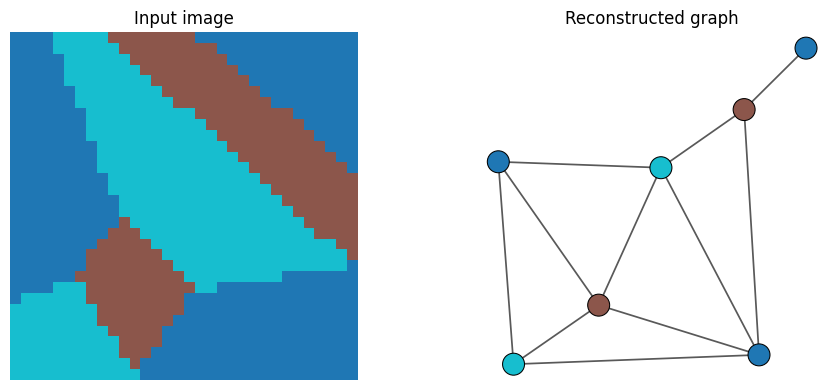

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_image(sample.image, ax=axes[0], title='Input image')
plot_graph(
    graph.adjacency_matrix,
    graph.node_colors,
    node_positions=node_positions,
    ax=axes[1],
    title='Reconstructed graph',
)
figure.tight_layout()
plt.show()

## 7. Graph Canonization

In [11]:
from canonization import canonize_graph

print(np.allclose(graph.adjacency_matrix, sample.adjacency_matrix))
print(np.allclose(graph.node_colors, sample.node_colors))

canonized_adjacency1, canonized_colors1 = canonize_graph(graph)
canonized_adjacency2, canonized_colors2 = canonize_graph((graph.adjacency_matrix, graph.node_colors))

print(np.allclose(canonized_adjacency1, canonized_adjacency2))
print(np.allclose(canonized_colors1, canonized_colors2))


False
False
True
True
